# 6. Классификация изображений

Изображение, правильный класс, обучаемые веса

Данные: [digits_012.npz](data/digits_012.npz)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
plt.rcParams.update({'font.size': 12, 'axes.unicode_minus': False, 'figure.figsize': (10, 4)})
torch.set_num_threads(2)
torch.manual_seed(42)
np.random.seed(42)
data_path = Path('data/digits_012.npz')
if not data_path.exists():
    data_path = Path('digits_012.npz')
with np.load(data_path, allow_pickle=False) as data:
    images = data['images'].copy()
    labels = data['labels'].copy()
print('Изображений:', len(images), 'Классы:', np.unique(labels))

Изображений: 360 Классы: [0 1 2]


## 6.1 Класс - правильный ответ для изображения

Одна картинка, одна метка

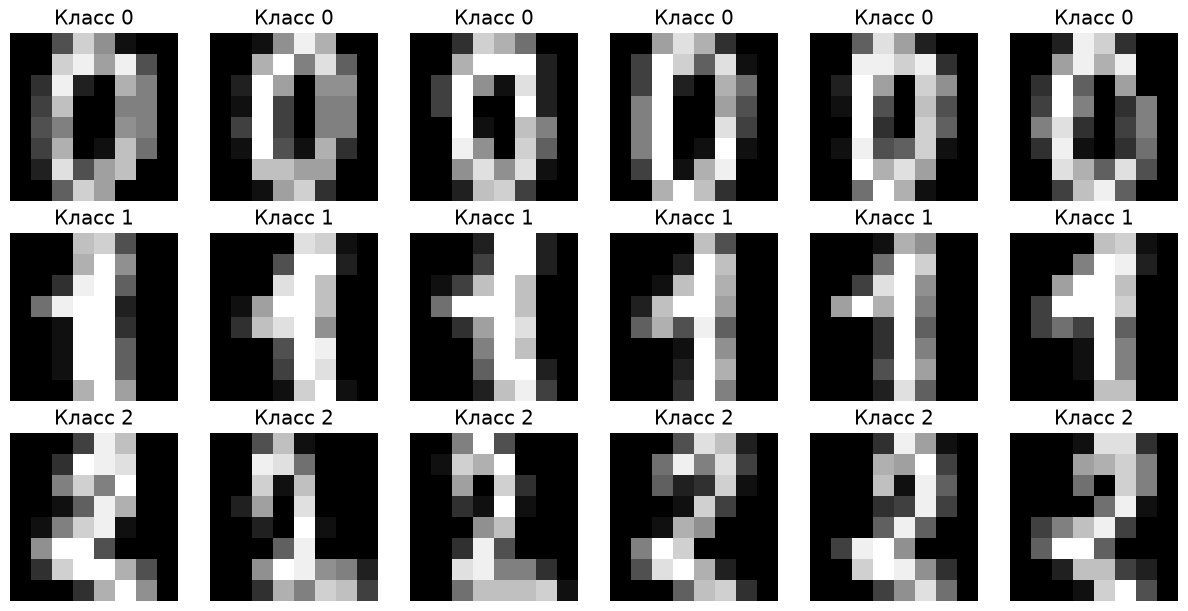

In [2]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6), layout='constrained')
for label, row in enumerate(axes):
    indices = np.flatnonzero(labels == label)[:6]
    for ax, i in zip(row, indices):
        ax.imshow(images[i], cmap='gray', vmin=0, vmax=16)
        ax.set_title(f'Класс {labels[i]}')
        ax.set_axis_off()
plt.show()

## 6.2 Массив становится тензором

Пиксели, масштаб значений, оси NCHW

In [3]:
print('Первое изображение:')
print(images[0])
print('Исходная форма:', images.shape)
x = torch.from_numpy(images.astype(np.float32) / 16.0).unsqueeze(1)
y = torch.from_numpy(labels).long()
print('Тензор NCHW:', tuple(x.shape), 'тип:', x.dtype)
print('Диапазон:', x.min().item(), x.max().item())
print('Одна метка:', y[0].item())

Первое изображение:
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]
Исходная форма: (360, 8, 8)
Тензор NCHW: (360, 1, 8, 8) тип: torch.float32
Диапазон: 0.0 1.0
Одна метка: 0


## 6.3 Сворачиваем участок изображения

Каждое значение умножается на свой вес, затем результаты складываются

Участок:
 [[0. 1. 2.]
 [0. 2. 4.]
 [0. 1. 2.]]
Веса:
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
Произведения:
 [[-0.  0.  2.]
 [-0.  0.  4.]
 [-0.  0.  2.]]
Сумма: 8.0


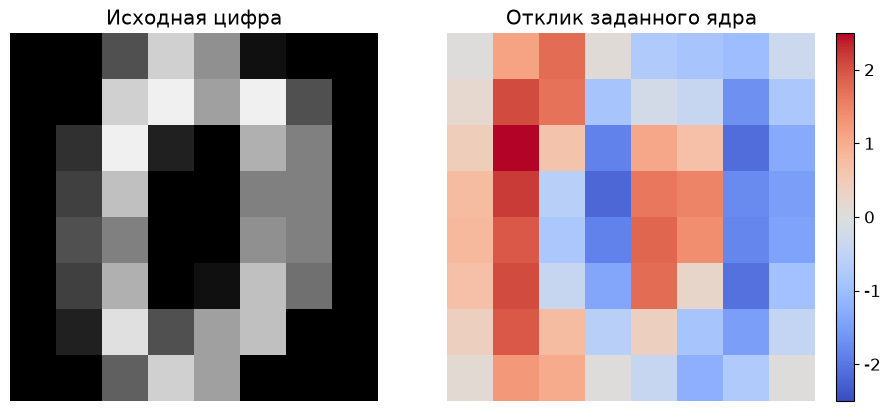

In [4]:
patch = np.array([[0., 1., 2.], [0., 2., 4.], [0., 1., 2.]])
kernel = np.array([[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]])
print('Участок:\n', patch)
print('Веса:\n', kernel)
print('Произведения:\n', patch * kernel)
print('Сумма:', np.sum(patch * kernel))
edge_kernel = torch.tensor(kernel, dtype=torch.float32)[None, None]
response = torch.nn.functional.conv2d(x[:1], edge_kernel, padding=1)[0, 0].numpy()
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')
axes[0].imshow(images[0], cmap='gray', vmin=0, vmax=16)
axes[0].set_title('Исходная цифра')
v = max(abs(response.min()), abs(response.max()))
m = axes[1].imshow(response, cmap='coolwarm', vmin=-v, vmax=v)
axes[1].set_title('Отклик заданного ядра')
fig.colorbar(m, ax=axes[1])
for ax in axes:
    ax.set_axis_off()
plt.show()

## 6.4 ReLU и MaxPool

Отрицательные отклики обнуляются, затем выбирается максимум в блоке

In [5]:
values = torch.tensor([[[[-2., 3., 1., 0.], [1., -1., 4., 2.], [0., 2., -3., 1.], [5., 1., 2., 0.]]]])
activated = torch.relu(values)
pooled = torch.nn.functional.max_pool2d(activated, 2)
print('До ReLU:\n', values[0, 0])
print('После ReLU:\n', activated[0, 0])
print('После MaxPool:\n', pooled[0, 0])

До ReLU:
 tensor([[-2.,  3.,  1.,  0.],
        [ 1., -1.,  4.,  2.],
        [ 0.,  2., -3.,  1.],
        [ 5.,  1.,  2.,  0.]])
После ReLU:
 tensor([[0., 3., 1., 0.],
        [1., 0., 4., 2.],
        [0., 2., 0., 1.],
        [5., 1., 2., 0.]])
После MaxPool:
 tensor([[3., 4.],
        [5., 2.]])


## 6.5 От признаков к классу

Последний слой выдает логиты, а не готовые вероятности

Логиты: tensor([[ 2.0000, -0.5000,  0.4000]])
Softmax: tensor([[0.7790, 0.0640, 0.1570]])
Сумма: 0.9999999403953552
Выбранный класс: 0


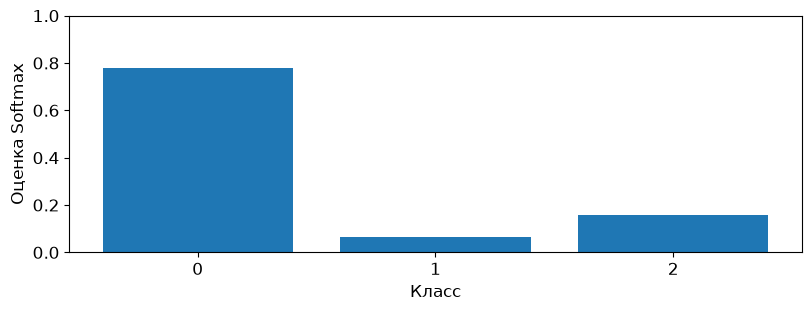

In [6]:
logits = torch.tensor([[2.0, -0.5, 0.4]])
probabilities = logits.softmax(dim=1)
print('Логиты:', logits)
print('Softmax:', probabilities.round(decimals=3))
print('Сумма:', probabilities.sum().item())
print('Выбранный класс:', logits.argmax(dim=1).item())
fig, ax = plt.subplots(figsize=(8, 3), layout='constrained')
ax.bar(['0', '1', '2'], probabilities[0].numpy())
ax.set(xlabel='Класс', ylabel='Оценка Softmax', ylim=(0, 1))
plt.show()

## 6.6 Ошибка и градиент

CrossEntropyLoss сравнивает логиты с правильным классом

In [7]:
learnable_logits = torch.tensor([[2.0, -0.5, 0.4]], requires_grad=True)
correct_class = torch.tensor([1])
loss = nn.CrossEntropyLoss()(learnable_logits, correct_class)
loss.backward()
print('Правильный класс:', correct_class.item())
print('Ошибка до шага:', loss.item())
print('Градиент по логитам:', learnable_logits.grad)
with torch.no_grad():
    new_logits = learnable_logits - 0.5 * learnable_logits.grad
print('Логиты после шага:', new_logits)
print('Ошибка после шага:', nn.CrossEntropyLoss()(new_logits, correct_class).item())

Правильный класс: 1
Ошибка до шага: 2.7499659061431885
Градиент по логитам: tensor([[ 0.7788, -0.9361,  0.1572]])
Логиты после шага: tensor([[ 1.6106, -0.0320,  0.3214]])
Ошибка после шага: 2.027116060256958


## 6.7 Три набора данных

Train меняет веса, validation выбирает состояние, test оценивает итог

In [8]:
rng = np.random.default_rng(42)
parts = {'train': [], 'validation': [], 'test': []}
for label in range(3):
    ids = rng.permutation(np.flatnonzero(labels == label))
    parts['train'].extend(ids[:84])
    parts['validation'].extend(ids[84:102])
    parts['test'].extend(ids[102:])
for name, ids in parts.items():
    parts[name] = np.array(ids)
    print(name, len(ids), 'По классам:', np.bincount(labels[ids], minlength=3))
loaders = {name: DataLoader(TensorDataset(x[ids], y[ids]), batch_size=32,
                            shuffle=(name == 'train'),
                            generator=torch.Generator().manual_seed(42))
           for name, ids in parts.items()}

train 252 По классам: [84 84 84]
validation 54 По классам: [18 18 18]
test 54 По классам: [18 18 18]


## 6.8 Небольшая CNN

Два сверточных слоя, уменьшение карт, три выходных числа

In [9]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(16 * 2 * 2, 3),
)
value = x[:2]
print('Вход:', tuple(value.shape))
for layer in model:
    value = layer(value)
    print(type(layer).__name__, '->', tuple(value.shape))

Вход: (2, 1, 8, 8)
Conv2d -> (2, 8, 8, 8)
ReLU -> (2, 8, 8, 8)
MaxPool2d -> (2, 8, 4, 4)
Conv2d -> (2, 16, 4, 4)
ReLU -> (2, 16, 4, 4)
MaxPool2d -> (2, 16, 2, 2)
Flatten -> (2, 64)
Linear -> (2, 3)


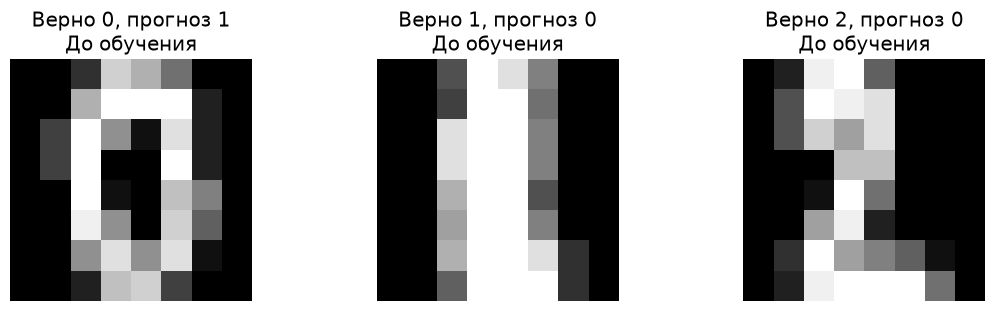

In [10]:
# Прогноз до изменения весов на нескольких обучающих примерах
preview_ids = np.array([parts['train'][np.flatnonzero(labels[parts['train']] == label)[0]] for label in range(3)])
with torch.no_grad():
    before = model(x[preview_ids]).softmax(dim=1).numpy()
fig, axes = plt.subplots(1, 3, figsize=(11, 3), layout='constrained')
for ax, i, scores in zip(axes, preview_ids, before):
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=16)
    ax.set_title(f'Верно {labels[i]}, прогноз {scores.argmax()}\nДо обучения')
    ax.set_axis_off()
plt.show()

## 6.9 Обучение

Ошибка, backward, шаг оптимизатора, проверка validation

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch, target in loader:
            output = model(batch)
            total_loss += criterion(output, target).item() * len(target)
            correct += (output.argmax(1) == target).sum().item()
            total += len(target)
    return total_loss / total, correct / total

history = []
best_loss = float('inf')
for epoch in range(1, 21):
    model.train()
    for batch, target in loaders['train']:
        optimizer.zero_grad()
        loss = criterion(model(batch), target)
        loss.backward()
        optimizer.step()
    train_loss, train_accuracy = evaluate(loaders['train'])
    val_loss, val_accuracy = evaluate(loaders['validation'])
    history.append([train_loss, val_loss, train_accuracy, val_accuracy])
    if val_loss < best_loss:
        best_loss, best_epoch = val_loss, epoch
        best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
    if epoch in [1, 5, 10, 15, 20]:
        print(f'Эпоха {epoch}: train loss={train_loss:.3f}, validation loss={val_loss:.3f}')
model.load_state_dict(best_state)
model.eval()
print('Выбранная эпоха:', best_epoch)

Эпоха 1: train loss=0.929, validation loss=0.934
Эпоха 5: train loss=0.061, validation loss=0.063
Эпоха 10: train loss=0.013, validation loss=0.037
Эпоха 15: train loss=0.040, validation loss=0.036
Эпоха 20: train loss=0.002, validation loss=0.009
Выбранная эпоха: 17


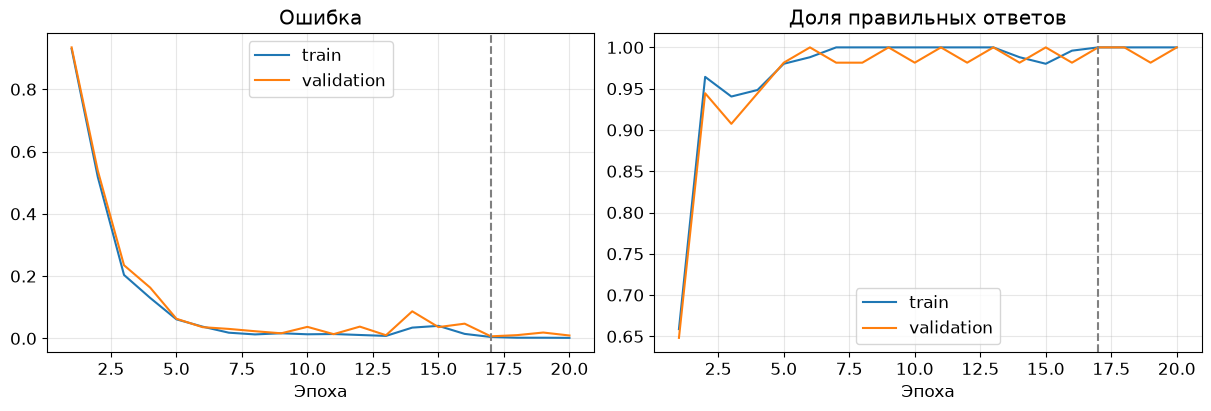

In [12]:
history = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for ax, columns, title in zip(axes, [(0, 1), (2, 3)], ['Ошибка', 'Доля правильных ответов']):
    for column, label in zip(columns, ['train', 'validation']):
        ax.plot(np.arange(1, 21), history[:, column], label=label)
    ax.axvline(best_epoch, color='gray', linestyle='--')
    ax.set(xlabel='Эпоха', title=title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.show()

## 6.10 Проверка на новых изображениях

Матрица ошибок: строки - правильный класс, столбцы - прогноз

Test: 54 изображений, accuracy=1.000
Постоянный прогноз: 0 accuracy: 0.3333333333333333


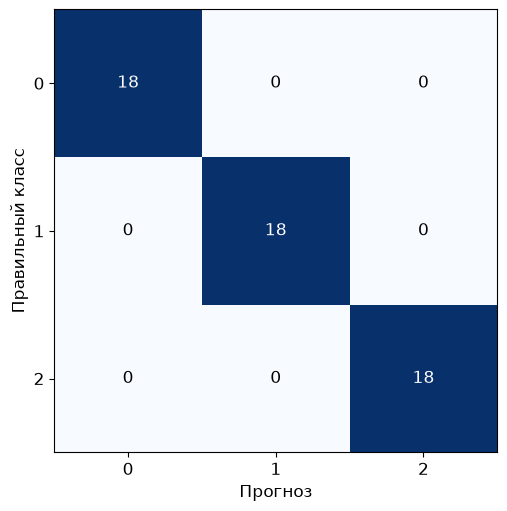

In [13]:
test_ids = parts['test']
with torch.no_grad():
    test_logits = model(x[test_ids])
    prediction = test_logits.argmax(1).numpy()
truth = labels[test_ids]
accuracy = np.mean(prediction == truth)
majority = np.bincount(labels[parts['train']]).argmax()
print(f'Test: {len(test_ids)} изображений, accuracy={accuracy:.3f}')
print('Постоянный прогноз:', majority, 'accuracy:', np.mean(truth == majority))
confusion = np.zeros((3, 3), dtype=int)
np.add.at(confusion, (truth, prediction), 1)
fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')
ax.imshow(confusion, cmap='Blues', vmin=0)
for i, j in np.ndindex(confusion.shape):
    ax.text(j, i, str(confusion[i, j]), ha='center', va='center', color='white' if confusion[i,j] > confusion.max()/2 else 'black')
ax.set(xticks=range(3), yticks=range(3), xlabel='Прогноз', ylabel='Правильный класс')
plt.show()

Ошибок: 0


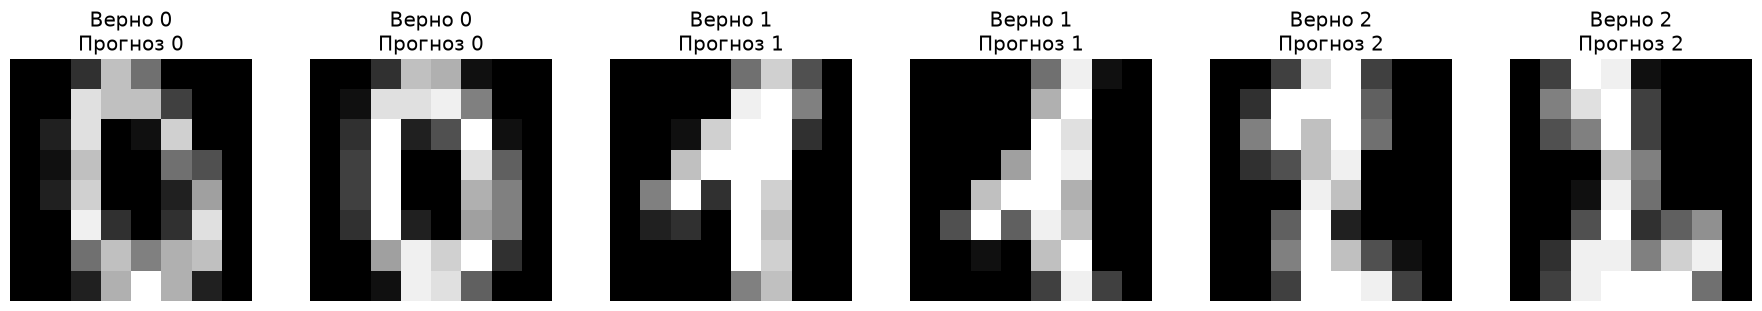

In [14]:
errors = np.flatnonzero(prediction != truth)
selected = errors[:6] if len(errors) else np.concatenate([np.flatnonzero(truth == label)[:2] for label in range(3)])
print('Ошибок:', len(errors))
fig, axes = plt.subplots(1, len(selected), figsize=(max(5, 3 * len(selected)), 3), squeeze=False, layout='constrained')
for ax, j in zip(axes[0], selected):
    ax.imshow(images[test_ids[j]], cmap='gray', vmin=0, vmax=16)
    ax.set_title(f'Верно {truth[j]}\nПрогноз {prediction[j]}')
    ax.set_axis_off()
plt.show()

In [15]:
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
torch.save({'state_dict': model.state_dict(), 'class_names': ['0', '1', '2'],
            'input_shape': [1, 8, 8], 'scale': 16.0}, output_dir / 'digits_demo.pt')
print('Сохранен файл outputs/digits_demo.pt')

Сохранен файл outputs/digits_demo.pt
